In [1]:
# For convenience, let's begin by enabling
# automatic reloading of modules when they change.
%load_ext autoreload
%autoreload 2

import numpy as np
from collections import OrderedDict
import os
import sys

import warnings
warnings.filterwarnings('ignore')

import qiskit_metal as metal
from qiskit_metal import designs
from qiskit_metal import MetalGUI, Dict

from qiskit_metal.toolbox_metal import math_and_overrides


from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder

from qiskit_metal.qlibrary.tlines.anchored_path import RouteAnchors

from qiskit_metal.qlibrary.qubits.circle_transmon import CircTransmon


from qiskit_metal.qlibrary.terminations.launchpad_wb_driven import LaunchpadWirebondDriven #bonding
from qiskit_metal.qlibrary.terminations.short_to_ground import ShortToGround


import pyEPR as epr
from qiskit_metal.analyses.quantization import EPRanalysis

from scipy.constants import c, e, hbar
from scipy.constants import physical_constants as pc

# Example of use of Circular Transmon design

This notebook shows how to create a circle transmon qubit using Qiskit Metal.

## Energy functions

These functions calculate the energy of the fluxonium qubit based on its parameters. Please check units before using them.

In [26]:
varphi_0 = pc['mag. flux quantum'][0]/ (2*np.pi) # in Wb

get_EC = lambda C_sigma: e**2 / (2*C_sigma*1e-6 * hbar * 2*np.pi) # in GHz, C_sigma in fF  OK!
get_EJ = lambda I0: I0 * varphi_0 / (2*np.pi*hbar) *1e-18 # I0 in nA and varphi_0 in Wb OK!
get_EL = lambda L: varphi_0**2 / (L*2*np.pi*hbar) # in GHz, L in nH  OK!

# for lambda/2 resonator (open)
get_Cr_ol2 = lambda f_0, Z0: np.pi / (2 * 2*np.pi*f_0 * Z0)*1e6 # in fF, omega_0 in GHz, Z0 in Ohm  OK!
get_Lr_ol2 = lambda f_0, Cr: 1 / ((2*np.pi*f_0)**2 * Cr) * 1e6 # in nH, omega_0 in GHz, Cr in fF    OK!

#for lambda/4 resonator
get_Cr_sl4 = lambda f_0, Z0: np.pi / (4 * 2*np.pi*f_0 * Z0)*1e6 # in fF, omega_0 in GHz, Z0 in Ohm  OK!
get_Lr_sl4 = lambda f_0, Cr: 1 / ((2*np.pi*f_0)**2 * Cr) * 1e6 # in nH, omega_0 in GHz, Cr in fF    OK!

# coupling coef
# get_g = lambda Cg, C_sigma, Cr, Zr: 2*e * Cg *1e15/ (C_sigma * Cr) * np.sqrt(hbar / (2*Zr)) / (2*np.pi*hbar) * 1e-6 # OK! 
get_g = lambda Cg, C_sigma, Cr, Zr: 2*e * Cg *1e15/ (C_sigma * Cr) * np.sqrt(hbar / (2*Zr)) / (2*np.pi*hbar) * 1e-6 # OK!
# resonator_len
res_len_lambda_2 = lambda eff, f: c/(2*np.sqrt(eff)*f)*1e3 # in mm
res_len_lambda_4 = lambda eff, f: c/(4*np.sqrt(eff)*f)*1e3 # in mm

## Chip setup

In [3]:
design = designs.DesignPlanar()
design.chips.main.material = 'silicon'

design.variables['cpw_width'] = '20um' #S from reference 2
design.variables['cpw_gap'] = '11um' #W from reference 2
design._chips['main']['size']['size_x'] = '5mm'
design._chips['main']['size']['size_y'] = '5mm'
design._chips['main']['size']['size_z'] = '-600um' #Our wafer thicknes is 525 um+/-10

# If you disable the next line with "overwrite_enabled", then you will need to
# delete a component [<component>.delete()] before recreating it.
design.overwrite_enabled = True

Gui start

In [4]:
gui = MetalGUI(design)

## Circular Transmon Pocket

In this section, we create a circular transmon design. In this notebook are listed all the parameters that can be modified.

In [29]:
options = Dict(
        # Position and orientation
        pos_x='1.8mm', pos_y='1.6mm', orientation=0, chip='main',
        cpw_width=design.variables['cpw_width'], cpw_gap=design.variables['cpw_gap'],

        # Pads (capacitor)
        pad_radius = '120um',
        pad_gap = '10um',

        # jj (mesoscopic: 0 or small junction: 1)
        jj_options=Dict(
            jj_width='5um',
            L_j = '40.7885nH',
            C_j = '0.72fF',
            export_mask = False,    # if True, draw a rectangle where the constriction will be made. If false, we keep a gap of jj_sim_gap in which we insert a jj element to make the simulation
            gds_cell_jj = 'gds_cell_jj',
            jj_sim_gap = '8um', # if we need a small junction, we can increase this gap
            ),
        
        # Coupled claws (2 claws allowed   )
        claw_a_options= Dict(
            make_claw=True,
            connector_location='90',  # 0 => 'west' arm, 90 => 'north' arm, 180 => 'east' arm
            claw_width='50um',
            claw_gap='30um',
            claw_length='200um',
            ground_spacing='10um',
            connector_length='70um',
            ),
        claw_b_options=Dict(
            make_claw=False,
            connector_location='0',  # 0 => 'west' arm, 90 => 'north' arm, 180 => 'east' arm
            claw_width='50um',
            claw_gap='30um',
            claw_length='100um',
            ground_spacing='10um',
            connector_length='50um',
            ),

        # Charge line
        charge_line=Dict(
            make_charge_line=True,
            location = '180', # 0 => 'west' arm, 90 => 'north' arm, 180 => 'east' arm. Must be different from claw_a and claw_b if they exist
            pad_radius='40um',
            pad_gap='40um', # gap between the pad and qubit
            ground_spacing='15um', # distance from the charge line to the ground
            line_length='100um',
            )
        )

# Create a fluxonium qubit with the Manucharyan design
qubit_1 = CircTransmon(design, 'Q1', options=options)


gui.rebuild()
gui.autoscale()

## Lumped ports and transmission line

In [6]:
x1 = '0.25mm'
y1 = '3.2mm'

ops_1 = Dict(chip='main', pos_x=x1, pos_y=y1, orientation='360', lead_length='10um', 
             pad_width='120um', pad_gap='61um', trace_width=design.variables['cpw_width'] , trace_gap=design.variables['cpw_gap'] )
LP1 = LaunchpadWirebondDriven(design, 'LP1', options = ops_1)

# Driven Launchpad 2

x2 = '3mm'
y2 = '3.2mm'
ops_2 = Dict(chip='main', pos_x=x2, pos_y=y2, orientation='180', lead_length='10um',
             pad_width='120um', pad_gap='61um', trace_width=design.variables['cpw_width'] , trace_gap=design.variables['cpw_gap'] )
LP2 = LaunchpadWirebondDriven(design, 'LP2', options = ops_2)


# Rebuild the GUI
gui.rebuild()
gui.autoscale()

## Conecto LP1 con el extremo izquierdo del capacitor
opt_line = Dict(chip='main', trace_width =design.variables['cpw_width'] ,
        trace_gap =design.variables['cpw_gap'] , fillet='0um', hfss_wire_bonds = True, lead=Dict(end_straight='0.0mm'),
        pin_inputs=Dict(start_pin=Dict(component='LP1', pin='tie'),
                        end_pin=Dict(component='LP2', pin='tie')
                        )
               )

linea_1 = RoutePathfinder(design, 'linea_1', options = opt_line )

# Rebuild the GUI
gui.rebuild()
gui.autoscale() 


In [7]:
# charge lumped port
ops_charge_line = Dict(chip='main', pos_x='0.5mm', pos_y='1.6mm', orientation='0', lead_length='10um',
             pad_width='120um', pad_gap='61um', trace_width=design.variables['cpw_width'] , trace_gap=design.variables['cpw_gap'] )

LPC = LaunchpadWirebondDriven(design, 'LPC', options = ops_charge_line)

# Rebuild the GUI
gui.rebuild()
gui.autoscale()


In [10]:
# Connect LPC with charge_line pad
# anchors_points = [(0.7, 2), (0.7, 2.5), (0.8, 2.5), (1, 1.6)]
# anchors_dict = OrderedDict({i: point for i, point in enumerate(anchors_points)})

opt_line_charge = Dict(chip='main', trace_width =design.variables['cpw_width'],
        trace_gap = design.variables['cpw_gap'], hfss_wire_bonds = True, lead=Dict(end_straight='0.0mm'),
        pin_inputs=Dict(start_pin=Dict(component='LPC', pin='tie'),
                        end_pin=Dict(component='Q1', pin='charge_line')
                        )
                )

con_charge_line = RoutePathfinder(design, 'con_charge_line', options = opt_line_charge )
gui.rebuild()
gui.autoscale()

## $\lambda/4$ resonator

In [11]:
## Estimation for the resonator length
eff=(11.9+1)/2 ## Si and Air
f=7e9  # Resonator frequency in Hz

stg1 = ShortToGround(design, 'stg1', options=Dict(chip='main', pos_x='1mm',  pos_y='2.3mm', orientation='180'))

In [12]:
jogs = OrderedDict()
jogs[0] = ["L", '400um']
jogs[1] = ["L", '100um']
# jogs[1] = ["L", '300um']
# jogs[2] = ["R", '200um']
l = res_len_lambda_4(eff, f)  # in mm
total_length = f'{l}mm'

opt_meander = Dict(
    trace_width= design.variables['cpw_width'] ,
    trace_gap= design.variables['cpw_gap'] ,
    hfss_wire_bonds= True,
    meander=Dict(
        spacing= '250um',
        asymmetry= '0um'),    
    total_length= total_length,
    fillet = '90um',
    pin_inputs=Dict(
        end_pin=Dict(
            component= 'Q1',
            pin= 'claw_a'),
        start_pin=Dict(
            component= 'stg1',
            pin= 'short')),
    lead=Dict(
        start_straight='0.02mm',
        end_straight='1.278mm',
        end_jogged_extension=jogs
        ),
)
meandro_1 = RouteMeander(design, 'meandro_1',  options=opt_meander)

# rebuild the GUI
gui.rebuild()
gui.autoscale()

## Simulations

## Resonance frequency

In [13]:
from qiskit_metal.analyses.quantization import EPRanalysis
eig_res = EPRanalysis(design, "hfss")
hfss_render = eig_res.sim.renderer    # that's the real render which perfom the link with ansys. We can use it, but it's like a low level manipulation of the design.
#hfss_render.start()

In [14]:
# This function is more easy to use than previous one, because it automatically creates the setup and analyze it.
# with this function you can change the parameters of the setup, like the number of modes, the maximum frequency, etc.
eig_res.sim.setup_update(n_modes = 1,
                        max_delta_f = 0.1,
                        min_freq_ghz = 1,
                        max_passes = 18)

In [15]:
# Now we can run the simulation. This will calculate the eigenmodes of the design and return the results. You have to specify the components that you want to simulate and the open terminals. If you don't specify the open terminals, it will be rendered connected to ground.
eig_res.sim.run(name="ResonatorEPR CircTransmon", components=['LP1', 'LP2', 'linea_1', 'meandro_1', 'stg1'], 
               open_terminations=[('meandro_1', 'end')], box_plus_buffer = True)
# The function add automatically _hfss to the name of the simulation, so you can use the same name for multiple simulations without problems.

INFO 07:08PM [connect_project]: Connecting to Ansys Desktop API...
INFO 07:08PM [load_ansys_project]: 	Opened Ansys App
INFO 07:08PM [load_ansys_project]: 	Opened Ansys Desktop v2024.2.1
INFO 07:08PM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Mac/Home/Documents/Ansoft/
	Project:   Project7
INFO 07:08PM [connect_design]: No active design found (or error getting active design).
INFO 07:08PM [connect]: 	 Connected to project "Project7". No design detected
INFO 07:08PM [connect_design]: 	Opened active design
	Design:    ResonatorEPR CircTransmon_hfss [Solution type: Eigenmode]
WARNING 07:08PM [connect_setup]: 	No design setup detected.
WARNING 07:08PM [connect_setup]: 	Creating eigenmode default setup.
INFO 07:08PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 07:08PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 07:08PM [analyze]: Analyzing setup Setup
07:10PM 45s INFO [get_f_convergence]: Saved convergences to 

In [16]:
# to store the data, we can extract
freqs = eig_res.get_frequencies()
freqs # also this is a pandas dataframe but only with the frequencies of the eigenmodes.

Design "ResonatorEPR CircTransmon_hfss" info:
	# eigenmodes    1
	# variations    1
Design "ResonatorEPR CircTransmon_hfss" info:
	# eigenmodes    1
	# variations    1


,,Freq. (GHz),Quality Factor
variation,mode,,
0,0,6.988793,inf


In [17]:
freq_free = eig_res.get_frequencies()['Freq. (GHz)'].values[0] # this is the frequency of the first eigenmode, which is the free resonator frequency.

Design "ResonatorEPR CircTransmon_hfss" info:
	# eigenmodes    1
	# variations    1
Design "ResonatorEPR CircTransmon_hfss" info:
	# eigenmodes    1
	# variations    1


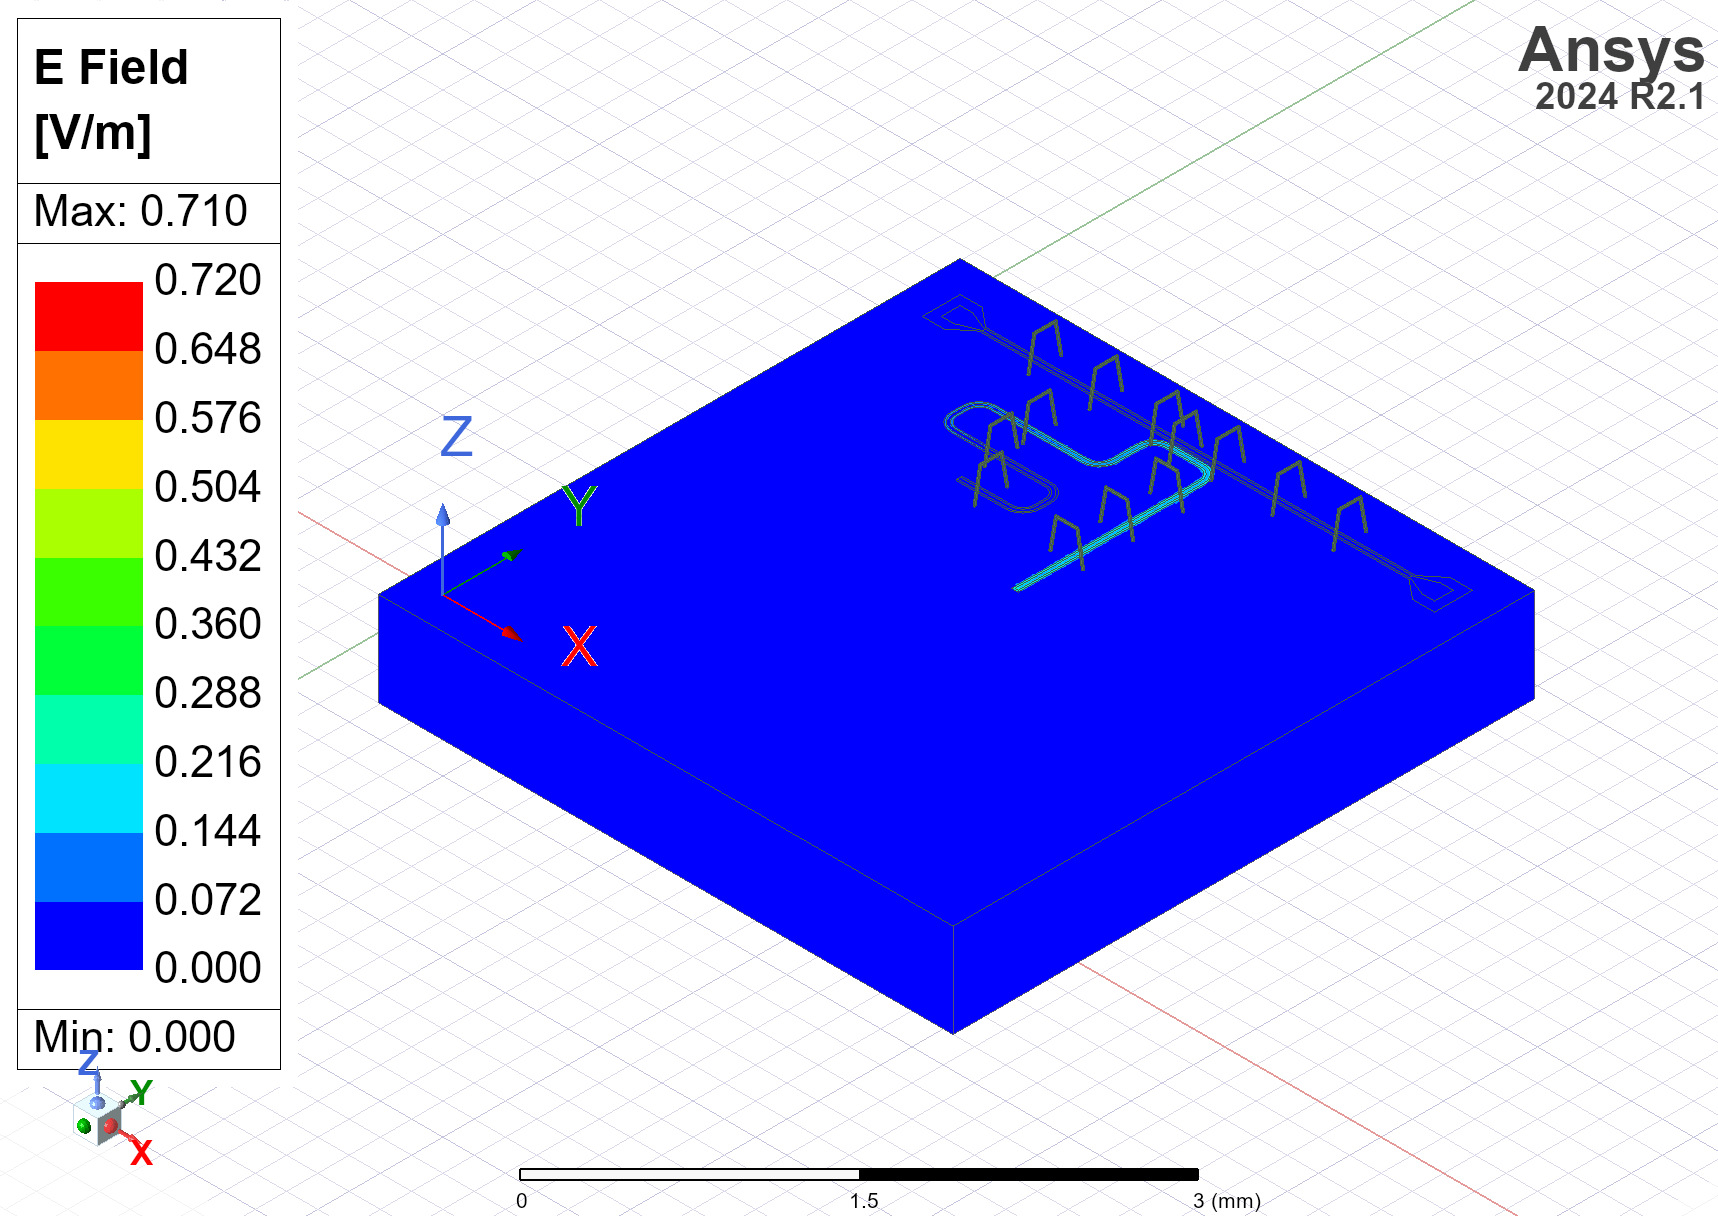

WindowsPath('y:/Tesis/src/libraries/qiskit_metal/Transmon Design Examples/ansys.png')

In [18]:
hfss_render.modeler._modeler.ShowWindow()
hfss_render.plot_fields('main')
hfss_render.save_screenshot()

In [19]:
Z0 = 50 # characteristic impedance of the resonator
Cr = get_Cr_sl4(freq_free, Z0)
Lr = get_Lr_sl4(freq_free, Cr)

print('Resonator free frequency: ', freq_free, 'GHz')
print('\tCr = ', Cr, 'fF')
print('\tLr = ', Lr, 'nH')

Resonator free frequency:  6.98879349625 GHz
	Cr =  357.7155343538815 fF
	Lr =  1.4497664539194646 nH


## Scattering matrix

## Capacitance extraction

In [30]:
from qiskit_metal.analyses.quantization import LOManalysis

c1 = LOManalysis(design, "q3d") # we use this class to perform the LOM analysis, which is a similiar than EPR analysis, but it performs electrostatic simulation to calculate the capacitance and inductance of the design. .
q3d = c1.sim.renderer   # this is the renderer that the class LOManalysis uses to perform the simulation. It is a low level manipulation of the design, so you can use it to perform the simulation without using the class LOManalysis.

In [31]:
# Now we can set the parameters for the simulation
c1.sim.sim_setup_name = "capacitances"
c1.sim.print_run_args()
c1.sim.setup.max_passes = 15
c1.sim.setup_update(solution_order = 'High', auto_increase_solution_order = 'True')

This analysis object run with the following kwargs:
{}



In [32]:
c1.sim.run(components=['Q1'], open_terminations=[('Q1', 'charge_line'), ('Q1', 'claw_a')], name='capacitance Q1') # all the components, all the terminations

INFO 07:21PM [connect_design]: 	Opened active design
	Design:    capacitance Q1_q3d [Solution type: Q3D]
INFO 07:21PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 07:21PM [analyze]: Analyzing setup Setup
INFO 07:23PM [get_matrix]: Exporting matrix data to (C:\Users\MAXIMI~1\AppData\Local\Temp\tmpdjp6z_tm.txt, C, , Setup:LastAdaptive, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 07:23PM [get_matrix]: Exporting matrix data to (C:\Users\MAXIMI~1\AppData\Local\Temp\tmpi7juoi1m.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 07:23PM [get_matrix]: Exporting matrix data to (C:\Users\MAXIMI~1\AppData\Local\Temp\tmp1ma5o4ga.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 2, False
INFO 07:23PM [get_matrix]: Exporting matrix data to (C:\Users\MAXIMI~1\AppData\Local\Temp\tmpbg5ivvls.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "f

In [33]:
cap_matrix_q1 = c1.sim.capacitance_matrix
cap_matrix_q1

,charge_line_Q1,claw_a_Q1,ground_main_plane,jj_area_0_Q1
charge_line_Q1,43.02682,-0.15728,-40.53148,-1.84372
claw_a_Q1,-0.15728,61.01125,-54.62741,-5.53394
ground_main_plane,-40.53148,-54.62741,242.93645,-101.97408
jj_area_0_Q1,-1.84372,-5.53394,-101.97408,111.78180


In [34]:
C1 = abs(cap_matrix_q1['jj_area_0_Q1']['ground_main_plane'])
Cg = abs(cap_matrix_q1['jj_area_0_Q1']['claw_a_Q1'])
Ccl = abs(cap_matrix_q1['jj_area_0_Q1']['charge_line_Q1'])

Zr = np.sqrt(Lr/Cr) * 1e3

EC_1 = get_EC(C1)
g = get_g(Cg, C1, Cr, Zr)

print('Qubit params')
print(f'\tC1: {C1:.4f} fF')
print(f'\tEC_1: {EC_1:.4f} GHz')

print('Resonator params')
print(f'\tf0: {freq_free:.4f} GHz')
print(f'\tCr: {Cr:.4f} fF')
print(f'\tLr: {Lr:.4f} nH')
print(f'\tZr: {Zr:.4f} Ohm')

print('Coupling params')
print(f'\tCg: {Cg:.4f} fF')
print(f'\tg: {g:.4f} MHz')
print(f'\tCcl: {Ccl:.4f} fF')

Qubit params
	C1: 101.9741 fF
	EC_1: 0.1900 GHz
Resonator params
	f0: 6.9888 GHz
	Cr: 357.7155 fF
	Lr: 1.4498 nH
	Zr: 63.6620 Ohm
Coupling params
	Cg: 5.5339 fF
	g: 66.7689 MHz
	Ccl: 1.8437 fF
